In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('income.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       22 non-null     object
 1   Age        22 non-null     int64 
 2   Income($)  22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes


In [5]:
df.isna().sum()

Name         0
Age          0
Income($)    0
dtype: int64

In [7]:
df = df.rename(columns={'Name': 'name', 'Age':'age', 'Income($)':'income'})

In [8]:
df.head()

,name,age,income
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


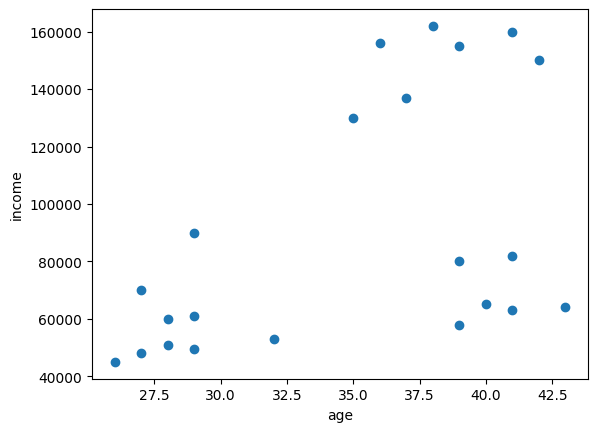

In [11]:
plt.scatter(df.age, df['income'])
plt.xlabel('age')
plt.ylabel('income')
plt.show()

In [9]:
X = df[['age']]
y = df['income']

In [13]:
kmeans = KMeans(n_clusters=3)
pred = kmeans.fit_predict(X, y)
pred

array([1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2],
      dtype=int32)

In [16]:
df['cluster'] = pred

In [18]:
kmeans.cluster_centers_

array([[41.33333333],
       [28.33333333],
       [37.57142857]])

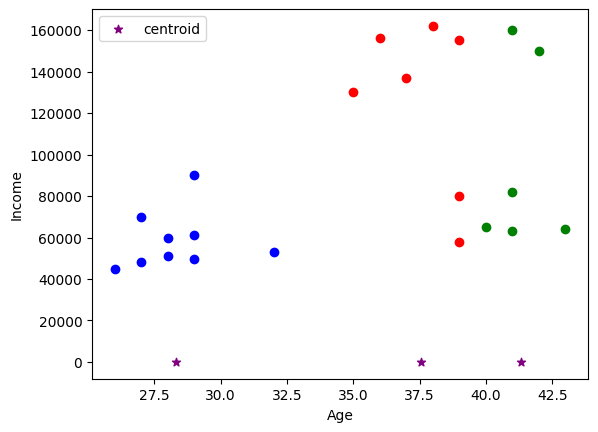

In [43]:
df0 = df[df.cluster == 0]
df1 = df[df.cluster == 1]
df2 = df[df.cluster == 2]

# Plotting the df(0, 1, 2) values 
plt.scatter(df0.age, df0['income'], color='green')
plt.scatter(df1.age, df1['income'], color='blue')
plt.scatter(df2.age, df2['income'], color='red')
# Plotting the model values
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 0],
            color='purple', marker='*', label='centroid')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()
plt.show()

### Preprocessing using min max scaler

In [17]:
df

,name,age,income,cluster
0,Rob,27,70000,1
1,Michael,29,90000,1
2,Mohan,29,61000,1
3,Ismail,28,60000,1
4,Kory,42,150000,0
5,Gautam,39,155000,2
6,David,41,160000,0
7,Andrea,38,162000,2
8,Brad,36,156000,2
9,Angelina,35,130000,2


In [48]:
# Income
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(df[['income']])
df['income'] = min_max_scaler.fit_transform(df[['income']])

# Age
min_max_scaler.fit(df[['age']])
df['age'] = min_max_scaler.fit_transform(df[['age']])

In [50]:
df.head()

,name,age,income,cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,0


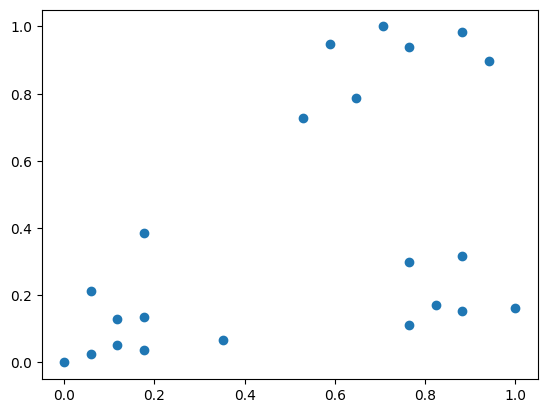

In [51]:
plt.scatter(df.age, df.income)

In [52]:
km = KMeans(n_clusters=3)
y_pred = km.fit_predict(df[['age', 'income']])
y_pred

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [53]:
df['cluster_2'] = y_pred

In [54]:
df

,name,age,income,cluster,cluster_2
0,Rob,0.058824,0.213675,1,0
1,Michael,0.176471,0.384615,1,0
2,Mohan,0.176471,0.136752,1,0
3,Ismail,0.117647,0.128205,1,0
4,Kory,0.941176,0.897436,0,1
5,Gautam,0.764706,0.940171,2,1
6,David,0.882353,0.982906,0,1
7,Andrea,0.705882,1.000000,2,1
8,Brad,0.588235,0.948718,2,1
9,Angelina,0.529412,0.726496,2,1


In [55]:
km.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ],
       [0.85294118, 0.2022792 ]])

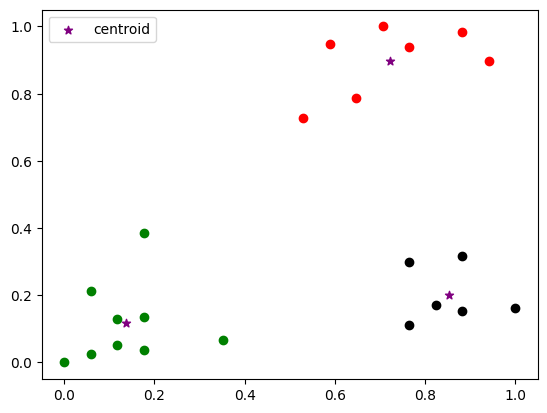

In [56]:
df1 = df[df.cluster_2 == 0]
df2 = df[df.cluster_2 == 1]
df3 = df[df.cluster_2 == 2]
plt.scatter(df1.age,df1['income'], color='green')
plt.scatter(df2.age,df2['income'], color='red')
plt.scatter(df3.age,df3['income'], color='black')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()
plt.show()

### Elbow Plot

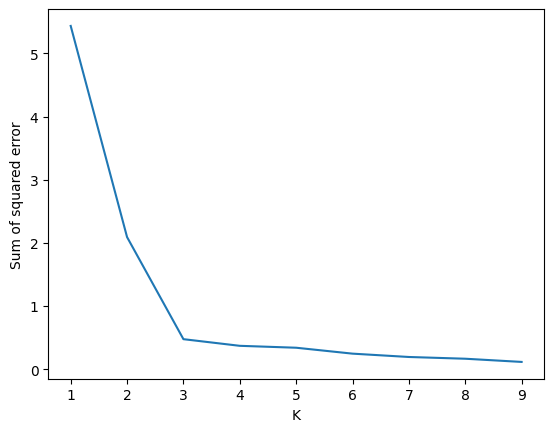

In [58]:
sum_se = []
km_range = range(1, 10)
for k in km_range: 
    km = KMeans(n_clusters= k)
    km.fit(df[['age', 'income']])
    sum_se.append(km.inertia_)

plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(km_range, sum_se)